In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# تحميل البيانات
df = pd.read_csv('Car Sales.xlsx - car_data.csv')

print(f"✅ عدد الصفوف: {len(df)}")
print(f"✅ الأعمدة: {list(df.columns)}")
df.head()

✅ عدد الصفوف: 23906
✅ الأعمدة: ['Car_id', 'Date', 'Customer Name', 'Gender', 'Annual Income', 'Dealer_Name', 'Company', 'Model', 'Engine', 'Transmission', 'Color', 'Price ($)', 'Dealer_No ', 'Body Style', 'Phone', 'Dealer_Region']


,Car_id,Date,Customer Name,Gender,Annual Income,Dealer_Name,Company,Model,Engine,Transmission,Color,Price ($),Dealer_No,Body Style,Phone,Dealer_Region
0,C_CND_000001,1/2/2022,Geraldine,Male,13500,Buddy Storbeck's Diesel Service Inc,Ford,Expedition,DoubleÂ Overhead Camshaft,Auto,Black,26000,06457-3834,SUV,8264678,Middletown
1,C_CND_000002,1/2/2022,Gia,Male,1480000,C & M Motors Inc,Dodge,Durango,DoubleÂ Overhead Camshaft,Auto,Black,19000,60504-7114,SUV,6848189,Aurora
2,C_CND_000003,1/2/2022,Gianna,Male,1035000,Capitol KIA,Cadillac,Eldorado,Overhead Camshaft,Manual,Red,31500,38701-8047,Passenger,7298798,Greenville
3,C_CND_000004,1/2/2022,Giselle,Male,13500,Chrysler of Tri-Cities,Toyota,Celica,Overhead Camshaft,Manual,Pale White,14000,99301-3882,SUV,6257557,Pasco
4,C_CND_000005,1/2/2022,Grace,Male,1465000,Chrysler Plymouth,Acura,TL,DoubleÂ Overhead Camshaft,Auto,Red,24500,53546-9427,Hatchback,7081483,Janesville


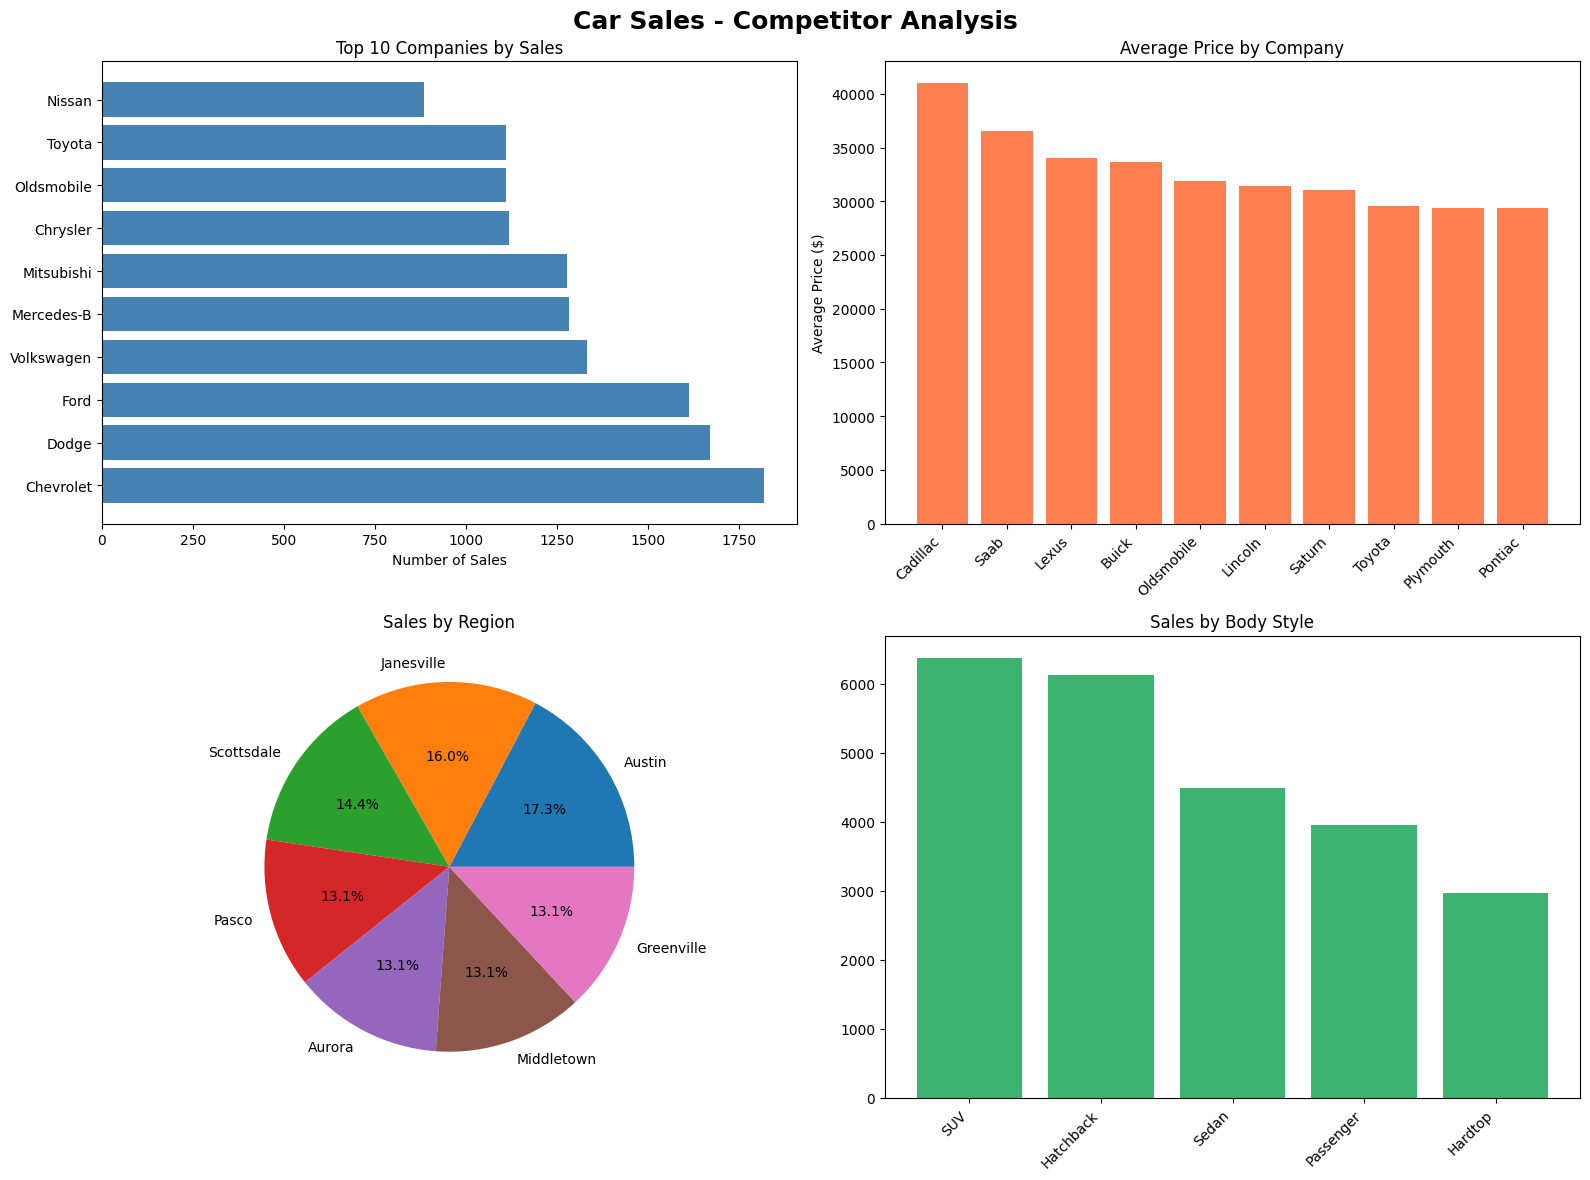

✅ Chart اتحفظ!


In [2]:
# ==============================
# تحليل المنافسين
# ==============================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Car Sales - Competitor Analysis', fontsize=18, fontweight='bold')

# 1. أكتر Company مبيعاً
top_companies = df['Company'].value_counts().head(10)
axes[0,0].barh(top_companies.index, top_companies.values, color='steelblue')
axes[0,0].set_title('Top 10 Companies by Sales')
axes[0,0].set_xlabel('Number of Sales')

# 2. متوسط السعر لكل Company
avg_price = df.groupby('Company')['Price ($)'].mean().sort_values(ascending=False).head(10)
axes[0,1].bar(avg_price.index, avg_price.values, color='coral')
axes[0,1].set_title('Average Price by Company')
axes[0,1].set_xticklabels(avg_price.index, rotation=45, ha='right')
axes[0,1].set_ylabel('Average Price ($)')

# 3. المبيعات بالـ Region
region_sales = df['Dealer_Region'].value_counts()
axes[1,0].pie(region_sales.values, labels=region_sales.index, autopct='%1.1f%%')
axes[1,0].set_title('Sales by Region')

# 4. توزيع الـ Body Style
body_style = df['Body Style'].value_counts()
axes[1,1].bar(body_style.index, body_style.values, color='mediumseagreen')
axes[1,1].set_title('Sales by Body Style')
axes[1,1].set_xticklabels(body_style.index, rotation=45, ha='right')

plt.tight_layout()
plt.savefig('competitor_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart اتحفظ!")

In [3]:
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment
from openpyxl.drawing.image import Image

wb = Workbook()
ws = wb.active
ws.title = "Competitor Analysis"

# Header
ws["A1"] = "Car Sales - Competitor Analysis Report"
ws["A1"].font = Font(bold=True, size=16, color="FFFFFF")
ws["A1"].fill = PatternFill(start_color="1A5276", end_color="1A5276", fill_type="solid")
ws.merge_cells("A1:E1")
ws["A1"].alignment = Alignment(horizontal="center")

ws["A2"] = f"تاريخ التقرير: {datetime.now().strftime('%Y-%m-%d')}"
ws["A2"].font = Font(italic=True, color="888888")

# إضافة الـ Chart
img = Image("competitor_analysis.png")
img.width = 800
img.height = 500
ws.add_image(img, "A4")

# حفظ
wb.save("competitor_report.xlsx")
print("✅ Report اتحفظ!")

✅ Report اتحفظ!
